In [39]:
# CIT652: Chicago Crime Incidents - Predictive Analytics and Real-Time Stream Processing
# Installing required packages

# !pip install pyspark findspark wget pandas matplotlib seaborn scikit-learn plotly numpy -q

In [40]:
import findspark

findspark.init()

In [41]:
from pyspark import SparkContext, SparkConf

from pyspark.sql import SparkSession

In [42]:
# Creating a SparkContext object
sc = SparkContext.getOrCreate()

# Creating a SparkSession
spark = SparkSession \
    .builder \
    .appName("Chicago Crime Analytics") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

# Set log level
spark.sparkContext.setLogLevel("ERROR")

In [43]:
# Import required libraries
import pandas as pd
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime


print("Loading Chicago Crimes dataset...")

df = spark.read.format("csv")\
  .option("header", "true")\
  .option("inferSchema", "false")\
  .load("Crimes_-_2024_20260603.csv")
  
print("Dataset loaded successfully!")
print("creating temp view...")
df.createOrReplaceTempView("dfTable")
print("Temp view created successfully!")

Loading Chicago Crimes dataset...
Dataset loaded successfully!
creating temp view...
Temp view created successfully!


In [44]:
# PART 01: DATA INSPECTION AND INITIAL EXPLORATION
print(f"\nDataset Shape: {df.count()} rows, {len(df.columns)} columns")
print("\nColumn Names and Data Types:")
df.printSchema()

print("\nFirst 5 rows:")
df.show(5, truncate=False)


Dataset Shape: 259151 rows, 22 columns

Column Names and Data Types:
root
 |-- ID: string (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)


First 5 rows:
+--------+-----------

In [45]:
#  Adjust The Data Type for the columns

#  1) Date......
df = df.withColumn("Date", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))
df = df.withColumn("Updated On", to_timestamp(col("Updated On"), "MM/dd/yyyy hh:mm:ss a"))

#  2) Numbers.....
df = df.withColumn("ID",             col("ID").cast(LongType()))
df = df.withColumn("Beat",           col("Beat").cast(IntegerType()))
df = df.withColumn("District",       col("District").cast(IntegerType()))
df = df.withColumn("Ward",           col("Ward").cast(IntegerType()))
df = df.withColumn("Community Area", col("Community Area").cast(IntegerType()))
df = df.withColumn("X Coordinate",   col("X Coordinate").cast(DoubleType()))
df = df.withColumn("Y Coordinate",   col("Y Coordinate").cast(DoubleType()))
df = df.withColumn("Year",           col("Year").cast(IntegerType()))
df = df.withColumn("Latitude",       col("Latitude").cast(DoubleType()))
df = df.withColumn("Longitude",      col("Longitude").cast(DoubleType()))

# 3) Boolean......
df = df.withColumn("Arrest",   when(col("Arrest")   == "true", 1).otherwise(0))
df = df.withColumn("Domestic", when(col("Domestic") == "true", 1).otherwise(0))
# Create binary columns for modeling
df = df.withColumn("Arrest_Binary", when(col("Arrest") == 1, 1).otherwise(0))
df = df.withColumn("Domestic_Binary", when(col("Domestic") == 1, 1).otherwise(0))

# 4) Date Features.....
df = df.withColumn("Hour",       hour(col("Date")))
df = df.withColumn("DayOfWeek",  dayofweek(col("Date")))
df = df.withColumn("Month",      month(col("Date")))
df = df.withColumn("IsWeekend",  when(dayofweek(col("Date")).isin([1, 7]), 1).otherwise(0))
df = df.withColumn("IsNight",    when((hour(col("Date")) >= 20) | (hour(col("Date")) < 6), 1).otherwise(0))

In [46]:
# Show null counts for each column
null_counts = df.select([
    sum(isnull(col(c)).cast("int")).alias(c)
    for c in df.columns
])

expr = "stack({}, {}) as (column_name, null_count)".format(
    len(df.columns),
    ",".join([f"'{c}', `{c}`" for c in df.columns])
)

null_counts.selectExpr(expr).show(30, truncate=False)

+--------------------+----------+
|column_name         |null_count|
+--------------------+----------+
|ID                  |0         |
|Case Number         |0         |
|Date                |0         |
|Block               |0         |
|IUCR                |0         |
|Primary Type        |0         |
|Description         |0         |
|Location Description|1146      |
|Arrest              |0         |
|Domestic            |0         |
|Beat                |0         |
|District            |0         |
|Ward                |0         |
|Community Area      |7         |
|FBI Code            |0         |
|X Coordinate        |1623      |
|Y Coordinate        |1623      |
|Year                |0         |
|Updated On          |0         |
|Latitude            |1623      |
|Longitude           |1623      |
|Location            |1623      |
|Arrest_Binary       |0         |
|Domestic_Binary     |0         |
|Hour                |0         |
|DayOfWeek           |0         |
|Month        

In [47]:
duplicate_count = df.count() - df.dropDuplicates().count()
print(f"Duplicate records: {duplicate_count}")

Duplicate records: 0


# PART 01: Start Cleaning on the Data:

In [48]:
# Replace the Null Cell in the Location Description by "UNKNOWN"

df = df.fillna({"Location Description": "UNKNOWN"})

# Remove the Rows that have Null...
df = df.dropna(
    subset=[
        "Community Area",
        "X Coordinate",
        "Y Coordinate",
        "Latitude",
        "Longitude"
    ]
)

# Drop the Location Column since we have all of "latitude" & "longitude".
df = df.drop("Location")

In [49]:
# Change all of 'arrest' and 'document' Columns From "T/F" To "0/1".......

df = (
    df
    .withColumn("Arrest", col("Arrest").cast("int"))
    .withColumn("Domestic", col("Domestic").cast("int"))
)

# Data After Cleaning...

In [72]:
# Show wish Colum has a null.....

null_counts = df.select([
    sum(isnull(col(c)).cast("int")).alias(c)
    for c in df.columns
])

expr = "stack({}, {}) as (column_name, null_count)".format(
    len(df.columns),
    ",".join([f"'{c}', `{c}`" for c in df.columns])
)

null_counts.selectExpr(expr).show(30, truncate=False)


+--------------------+----------+
|column_name         |null_count|
+--------------------+----------+
|ID                  |0         |
|Case Number         |0         |
|Date                |0         |
|Block               |0         |
|IUCR                |0         |
|Primary Type        |0         |
|Description         |0         |
|Location Description|0         |
|Arrest              |0         |
|Domestic            |0         |
|Beat                |0         |
|District            |0         |
|Ward                |0         |
|Community Area      |0         |
|FBI Code            |0         |
|X Coordinate        |0         |
|Y Coordinate        |0         |
|Year                |0         |
|Updated On          |0         |
|Latitude            |0         |
|Longitude           |0         |
|Arrest_Binary       |0         |
|Domestic_Binary     |0         |
|Hour                |0         |
|DayOfWeek           |0         |
|Month               |0         |
|IsWeekend    

In [51]:
# The Data type After Cleaning....
df.printSchema()

root
 |-- ID: long (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = false)
 |-- Arrest: integer (nullable = false)
 |-- Domestic: integer (nullable = false)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: double (nullable = true)
 |-- Y Coordinate: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: timestamp (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Arrest_Binary: integer (nullable = false)
 |-- Domestic_Binary: integer (nullable = false)
 |-- Hour: integer (nullable = true)


In [52]:
df.limit(10).toPandas()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Updated On,Latitude,Longitude,Arrest_Binary,Domestic_Binary,Hour,DayOfWeek,Month,IsWeekend,IsNight
0,13709672,JJ101940,2024-12-31 23:58:00,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,0,0,...,2025-11-02 15:41:09,41.771470,-87.590742,0,0,23,3,12,0,1
1,13707925,JJ100089,2024-12-31 23:56:00,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,1,1,...,2025-05-17 16:40:52,41.808501,-87.616563,1,1,23,3,12,0,1
2,13708038,JJ100035,2024-12-31 23:55:00,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,0,1,...,2025-11-02 15:41:09,41.752749,-87.741498,0,1,23,3,12,0,1
3,13709164,JJ101392,2024-12-31 23:53:00,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,0,0,...,2025-11-02 15:41:09,41.774269,-87.599710,0,0,23,3,12,0,1
4,13707823,JJ100020,2024-12-31 23:50:00,012XX N MENARD AVE,0460,BATTERY,SIMPLE,SIDEWALK,0,0,...,2025-05-17 16:40:52,41.902858,-87.770537,0,0,23,3,12,0,1
5,13707839,JJ100021,2024-12-31 23:46:00,021XX W CULLERTON ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,0,1,...,2025-05-17 16:40:52,41.854884,-87.679008,0,1,23,3,12,0,1
6,13707849,JJ100011,2024-12-31 23:45:00,018XX W MAYPOLE AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,0,0,...,2025-05-17 16:40:52,41.884152,-87.672933,0,0,23,3,12,0,1
7,13707986,JJ100019,2024-12-31 23:45:00,117XX S STATE ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,0,1,...,2025-11-02 15:41:09,41.681396,-87.622767,0,1,23,3,12,0,1
8,13707847,JJ100007,2024-12-31 23:42:00,029XX W CHICAGO AVE,1345,CRIMINAL DAMAGE,TO CITY OF CHICAGO PROPERTY,CTA BUS,0,0,...,2025-11-02 15:41:09,41.895635,-87.699348,0,0,23,3,12,0,1
9,13707836,JJ100034,2024-12-31 23:40:00,0000X S OAKLEY BLVD,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,0,0,...,2025-11-02 15:41:09,41.880749,-87.683951,0,0,23,3,12,0,1


# PART 02: EDA and Visualization:

**♦️ 1) Compute the total number of incidents and the distribution of incidents across primary crime types.**



In [53]:
# total number of incidents

print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 257521
Columns: 28


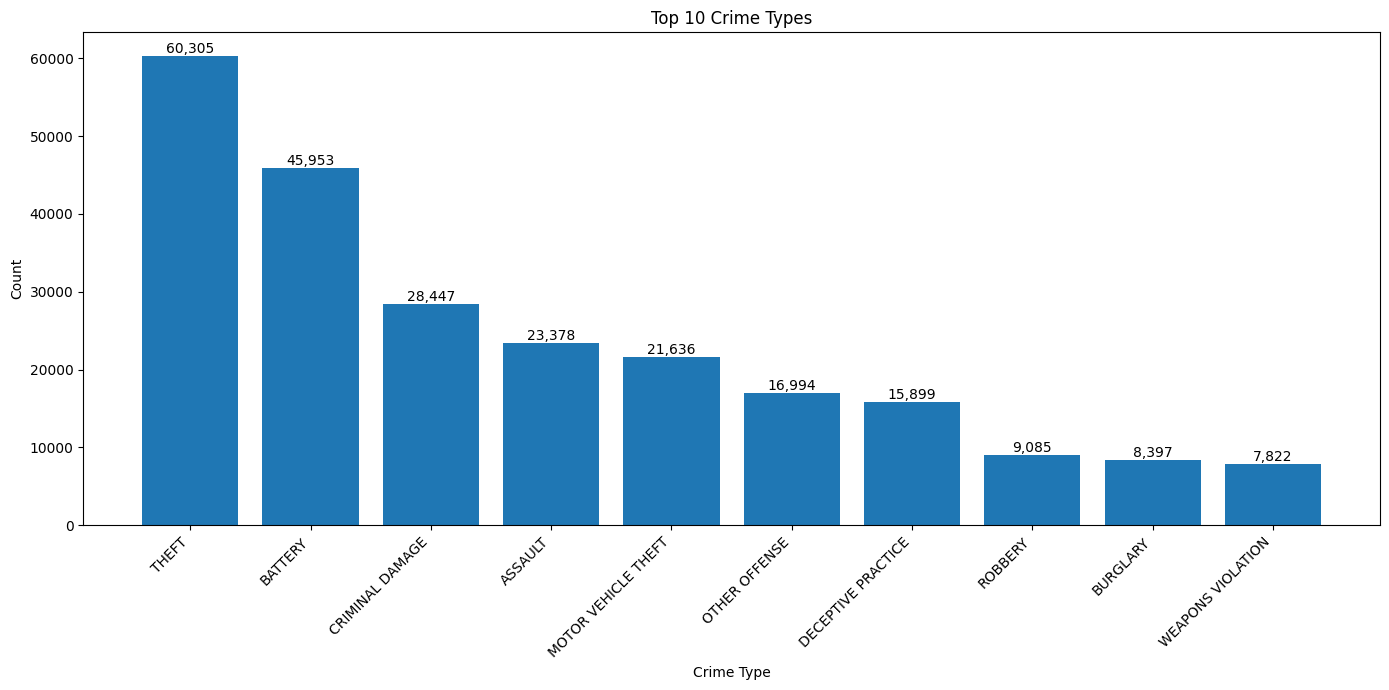

In [54]:
# Top 10 Crime Types

# Processing Data in PySpark first....
crime_counts = (
    df.groupBy("Primary Type")
      .count()
      .orderBy(desc("count"))
      .limit(10)
)

# Change To Pandas to make Visulisation......
crime_counts_pd = crime_counts.toPandas()


plt.figure(figsize=(14, 7))

ax = plt.bar(crime_counts_pd["Primary Type"], crime_counts_pd["count"])

for bar in ax: # To Wriet the Values UP the Columns
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )


plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**♦️ 2) Analyze arrest vs non-arrest incidents and domestic vs non-domestic incidents.**

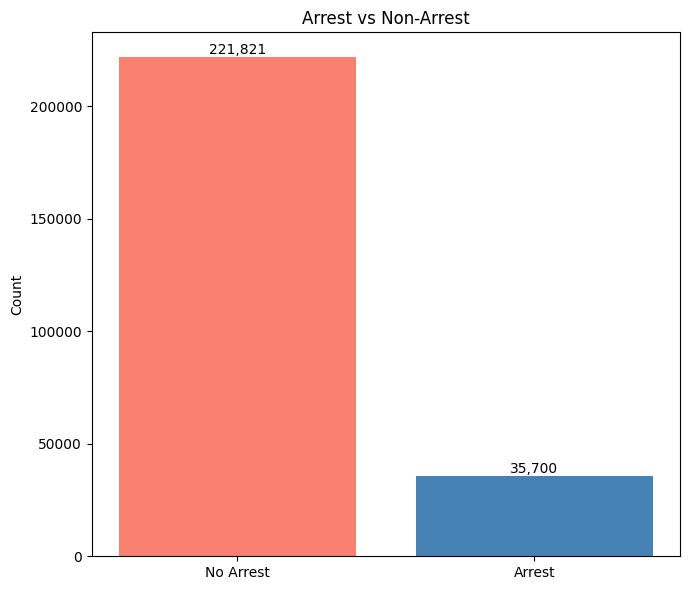

In [55]:
# Arrest vs Non-Arrest incidents.  جرائم التي تستدعي العتقال وعدم الاعتقال

arrest_counts = (
    df.groupBy("Arrest")
      .count()
      .orderBy("Arrest")
)

arrest_counts_pd = arrest_counts.toPandas()


plt.figure(figsize=(7, 6))

ax = plt.bar(
    arrest_counts_pd["Arrest"],
    arrest_counts_pd["count"],
    color=['salmon', 'steelblue']
)

for bar in ax:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.title("Arrest vs Non-Arrest")
plt.xticks([0, 1], ["No Arrest", "Arrest"])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

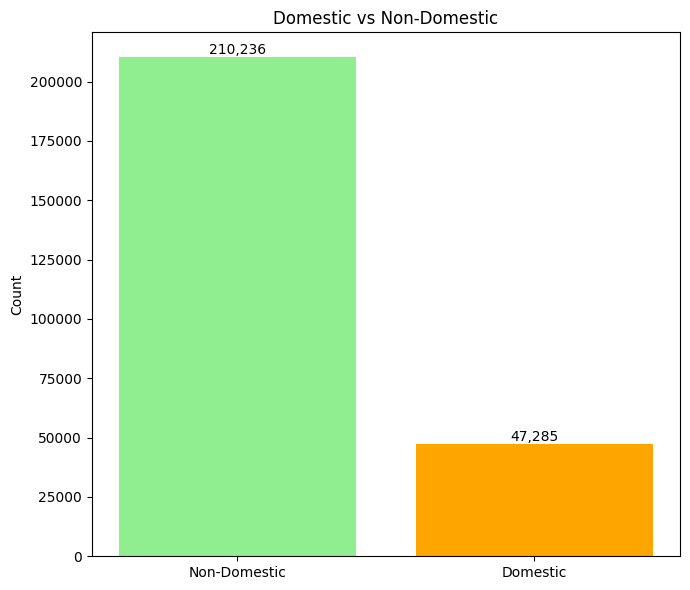

In [56]:
# Domestic vs Non-Domestic incidents.    حوادث العنف الأسري وغير الأسري  

domestic_counts = (
    df.groupBy("Domestic")
      .count()
      .orderBy("Domestic")
)

domestic_counts_pd = domestic_counts.toPandas()
plt.figure(figsize=(7, 6))
ax = plt.bar(
    domestic_counts_pd["Domestic"],
    domestic_counts_pd["count"],
    color=['lightgreen', 'orange']
)
for bar in ax:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )
plt.title("Domestic vs Non-Domestic")
plt.xticks([0, 1], ["Non-Domestic", "Domestic"])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**♦️ 3) Study trends by Hour, Day of week and Month to identify time-based crime patterns.**

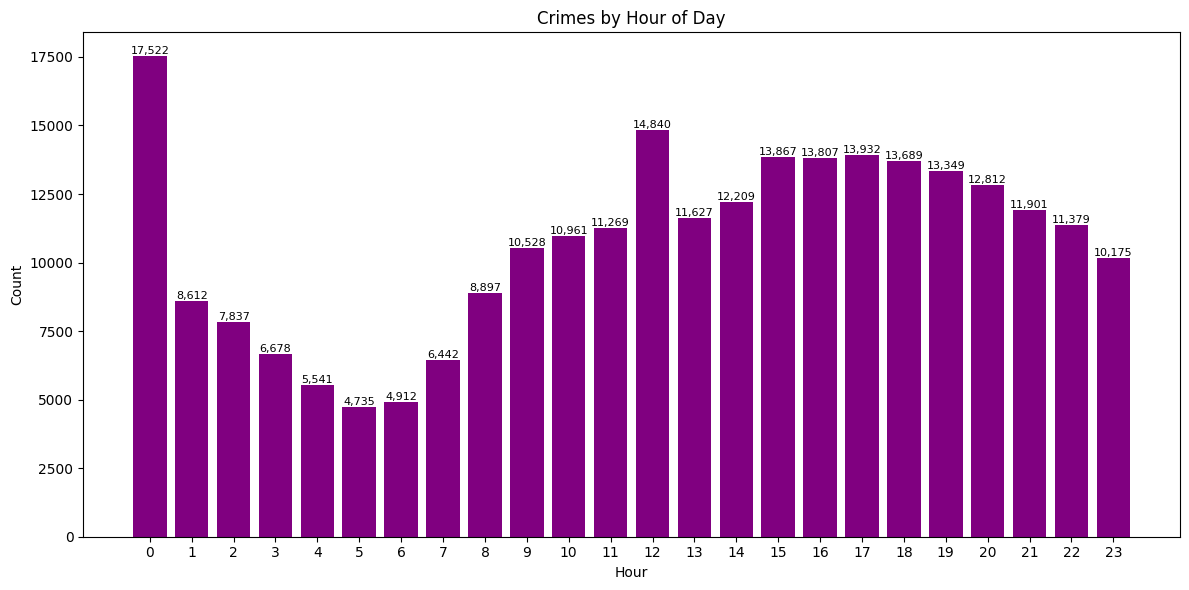

In [57]:
# Crimes by Hour...

hour_counts = (
    df.groupBy("Hour")
      .count()
      .orderBy(col("Hour"))
)

hour_counts_pd = hour_counts.toPandas()
plt.figure(figsize=(12, 6))
ax = plt.bar(
    hour_counts_pd["Hour"],
    hour_counts_pd["count"],
    color='purple'
)
for bar in ax:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=8
    )
plt.title("Crimes by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

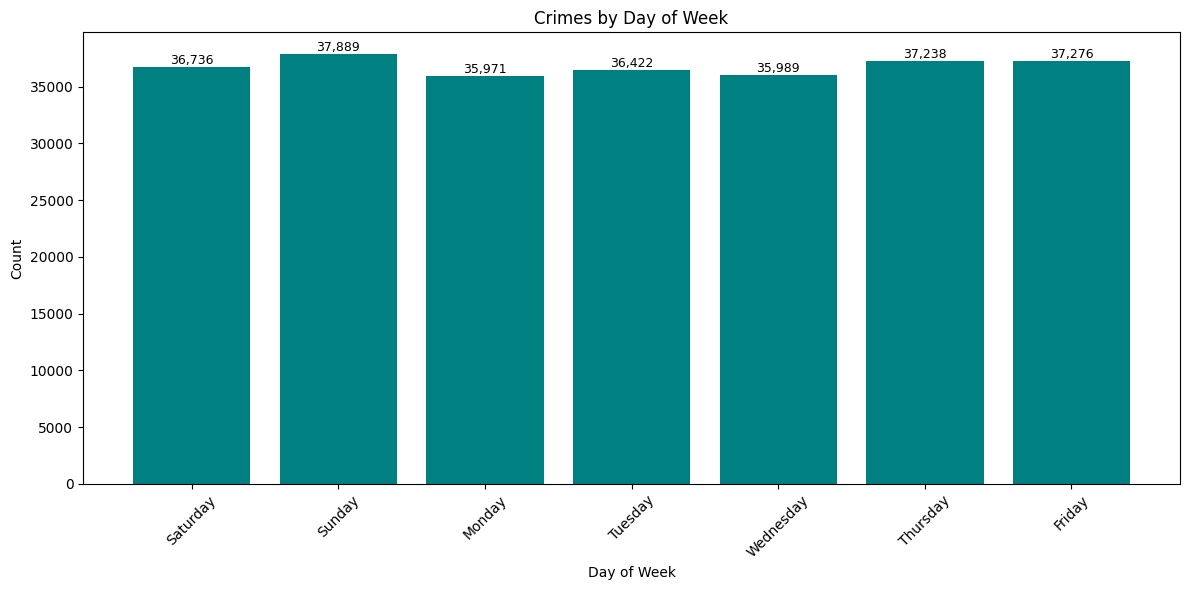

In [58]:
# Crimes by Day of Week

day_counts = (
    df.groupBy("DayOfWeek")
    .count()
    .orderBy("DayOfWeek")
)
day_counts_pd = day_counts.toPandas()
day_counts_pd = day_counts_pd.sort_values("DayOfWeek")
days = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
plt.figure(figsize=(12, 6))
bars = plt.bar(range(7), day_counts_pd["count"], color="teal")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9
    )
plt.title("Crimes by Day of Week")
plt.xticks(range(7), days, rotation=45)
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

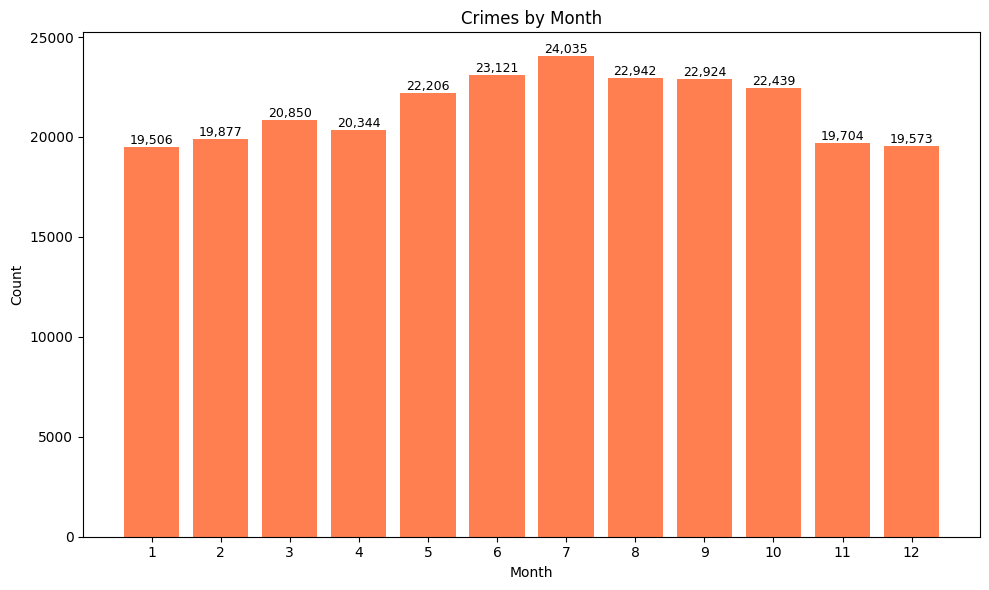

In [59]:
# Crimes by Month

month_counts = (
    df.groupBy("Month")
    .count()
    .orderBy("Month")
)
month_counts_pd = month_counts.toPandas()
month_counts_pd = month_counts_pd.sort_values("Month")
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(month_counts_pd)), month_counts_pd["count"], color="coral")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9
    )
plt.title("Crimes by Month")
plt.xticks(range(len(month_counts_pd)), range(1, len(month_counts_pd)+1), rotation=0)
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**♦️ 4) Identify the most common Districts, Beats, Wards, Community areas and High-frequency blocks.**

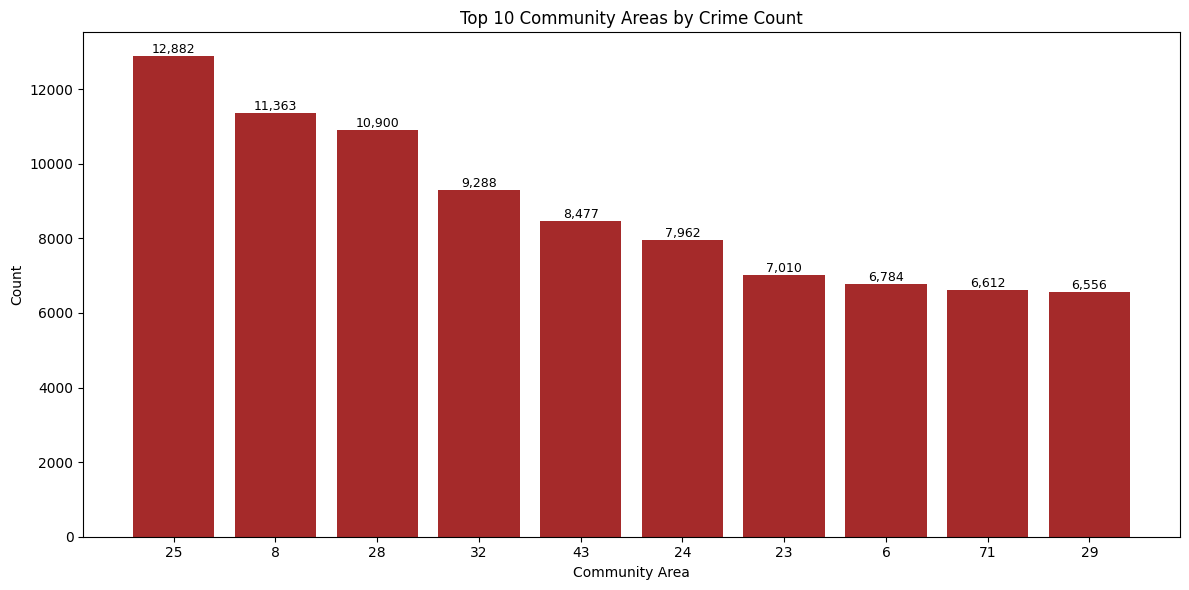

In [60]:
# Top 10 Community Areas...... افضل المناطق المجتمعية 

community_counts = (
    df.groupBy("Community Area")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
)
community_counts_pd = community_counts.toPandas()
community_counts_pd = community_counts_pd.sort_values("count", ascending=False)
plt.figure(figsize=(12, 6))
bars = plt.bar(range(10), community_counts_pd["count"], color="brown")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9
    )
plt.title("Top 10 Community Areas by Crime Count")
plt.xticks(range(10), community_counts_pd["Community Area"], rotation=0)
plt.xlabel("Community Area")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

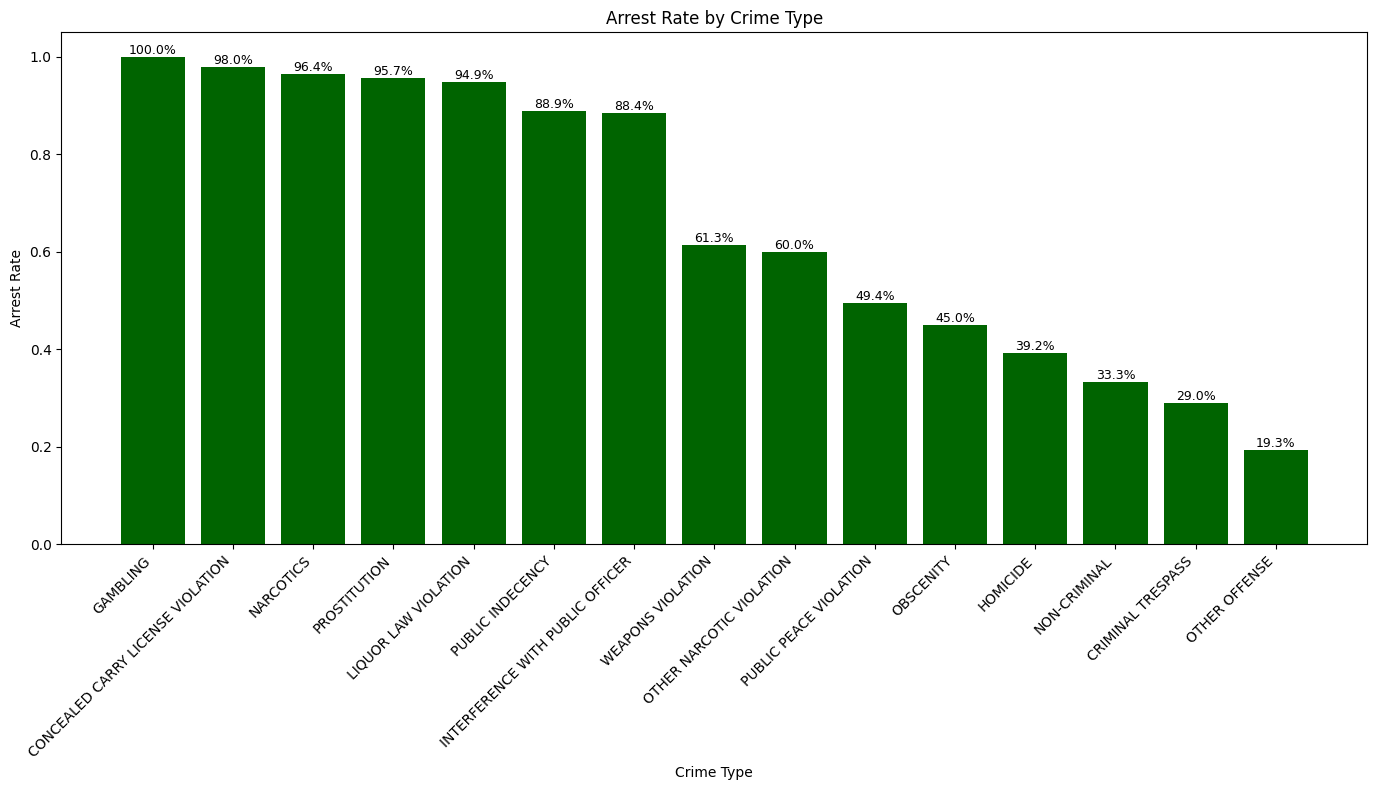

In [61]:
# Arrest Rate by Crime Type.....   معدل الاعتقالات حسب نوع الجريمة

arrest_rate = (
    df.groupBy("Primary Type")
    .agg({"Arrest": "mean"})
    .orderBy("avg(Arrest)", ascending=False)
    .limit(15)
)
arrest_rate_pd = arrest_rate.toPandas()
arrest_rate_pd = arrest_rate_pd.sort_values("avg(Arrest)", ascending=False)
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(arrest_rate_pd)), arrest_rate_pd["avg(Arrest)"], color="darkgreen")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1%}",
        ha="center", va="bottom", fontsize=9
    )
plt.title("Arrest Rate by Crime Type")
plt.xticks(range(len(arrest_rate_pd)), arrest_rate_pd["Primary Type"], rotation=45, ha="right")
plt.xlabel("Crime Type")
plt.ylabel("Arrest Rate")
plt.tight_layout()
plt.show()

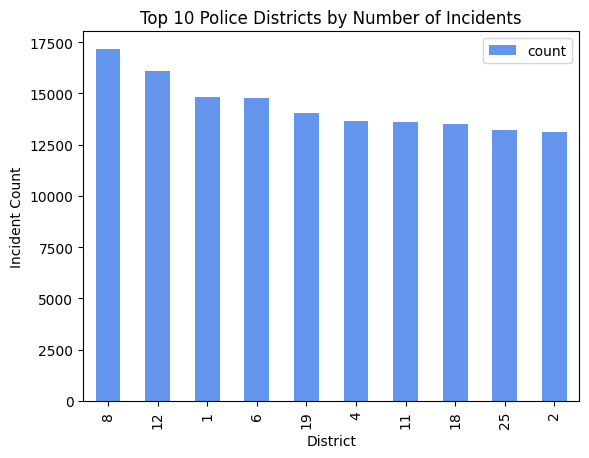

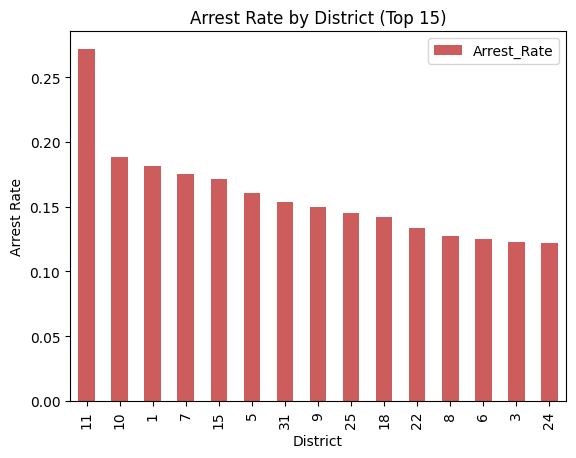

In [62]:
# Area summaries
top_districts_spark = df.groupBy('District').count().orderBy(desc('count')).limit(10)
top_districts_pd = top_districts_spark.toPandas()
top_districts_pd.plot(kind='bar', x='District', y='count', color='cornflowerblue')
plt.title('Top 10 Police Districts by Number of Incidents')
plt.ylabel('Incident Count')
plt.xlabel('District')
plt.show()
# Arrest rate by district matrix
district_arrest_spark = df.groupBy('District').agg(mean('Arrest').alias('Arrest_Rate')).orderBy(desc('Arrest_Rate')).limit(15)
district_arrest_pd = district_arrest_spark.toPandas()
district_arrest_pd.plot(kind='bar', x='District', y='Arrest_Rate', color='indianred')
plt.title('Arrest Rate by District (Top 15)')
plt.ylabel('Arrest Rate')
plt.xlabel('District')
plt.show()

In [63]:
# PREPARING DATA FOR MACHINE LEARNING
print("\n" + "=" * 80)
print("PREPARING DATA FOR MACHINE LEARNING")
print("=" * 80)

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Select features for modeling
feature_columns = ["Primary Type", "Description", "Location Description",
                   "District", "Beat", "Community Area", "FBI Code",
                   "Hour", "DayOfWeek", "Month", "IsWeekend", "IsNight", "Domestic_Binary"]

# String Indexers for categorical columns
indexers = [StringIndexer(inputCol=col, outputCol=col+"_Indexed").setHandleInvalid("keep")
            for col in ["Primary Type", "Description", "Location Description", "District", "Beat", "Community Area", "FBI Code"]]

# One Hot Encoders
encoders = [OneHotEncoder(inputCol=col+"_Indexed", outputCol=col+"_Encoded")
            for col in ["Primary Type", "Description", "Location Description", "District", "Beat", "Community Area", "FBI Code"]]

# Create pipeline for encoding
pipeline = Pipeline(stages=indexers + encoders)
df_encoded = pipeline.fit(df).transform(df)

print("Categorical encoding completed!")
print(f"Encoded dataframe rows: {df_encoded.count():,}")


PREPARING DATA FOR MACHINE LEARNING
Categorical encoding completed!
Encoded dataframe rows: 257,521


In [64]:
# Create feature vector
feature_vector_cols = (["Primary Type_Encoded", "Description_Encoded", "Location Description_Encoded", "Domestic_Binary",
                        "District_Encoded", "Beat_Encoded", "Community Area_Encoded", "FBI Code_Encoded"] +
                       ["Hour", "DayOfWeek", "Month", "IsWeekend", "IsNight"])

assembler = VectorAssembler(inputCols=feature_vector_cols, outputCol="features")
df_features = assembler.transform(df_encoded)

# Rename target column
df_final = df_features.select(col("Arrest_Binary").alias("label"), col("features"))

# Split data into training (80%) and validation (20%)
train_data, val_data = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"Training set size: {train_data.count():,} rows")
print(f"Validation set size: {val_data.count():,} rows")
print(f"Label distribution in training set:")
train_data.groupBy("label").count().show()

Training set size: 206,214 rows
Validation set size: 51,307 rows
Label distribution in training set:
+-----+------+
|label| count|
+-----+------+
|    1| 28419|
|    0|177795|
+-----+------+



# PART 03: CLASSIFICATION MODELS

In [65]:
# PART 03: CLASSIFICATION MODELS - PREDICT ARREST
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator


accuracy_evaluator  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
recall_evaluator    = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
f1_evaluator        = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_auc       = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# Dictionary to store model results
model_results = {}
confusion_matrices = {}
models = [
    ("Logistic Regression", LogisticRegression()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("Random Forest", RandomForestClassifier(numTrees=100, maxDepth=5))
]

# Train and evaluate each model
for model in models:
    print(f"\nTraining {model[0]}...")
    classifier = model[1]
    classifier_predictions = classifier.fit(train_data)\
    .transform(val_data)

    classifier_predictions_auc = evaluator_auc.evaluate(classifier_predictions)
    accuracy = accuracy_evaluator.evaluate(classifier_predictions)
    precision = precision_evaluator.evaluate(classifier_predictions)
    recall = recall_evaluator.evaluate(classifier_predictions)
    f1 = f1_evaluator.evaluate(classifier_predictions)

    model_results[model[0]] = {
        'AUC': classifier_predictions_auc,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    print(f"  {model[0]}  AUC: {classifier_predictions_auc:.2f}, Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

# Store results of confusion matrix
    confusion_matrices[model[0]] = classifier_predictions.crosstab("label", "prediction")


Training Logistic Regression...
  Logistic Regression  AUC: 0.88, Accuracy: 0.91, Precision: 0.91, Recall: 0.91, F1-Score: 0.90

Training Decision Tree...
  Decision Tree  AUC: 0.34, Accuracy: 0.90, Precision: 0.90, Recall: 0.90, F1-Score: 0.88

Training Random Forest...
  Random Forest  AUC: 0.82, Accuracy: 0.88, Precision: 0.89, Recall: 0.88, F1-Score: 0.83


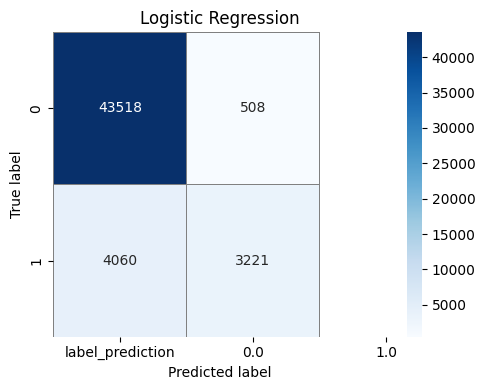

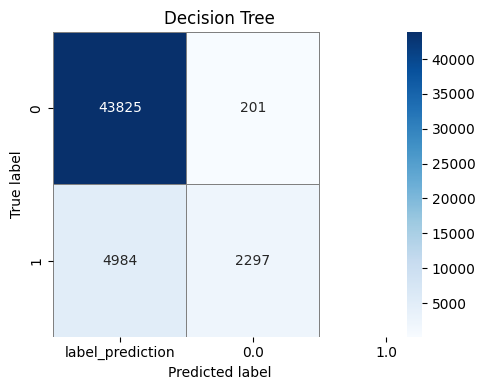

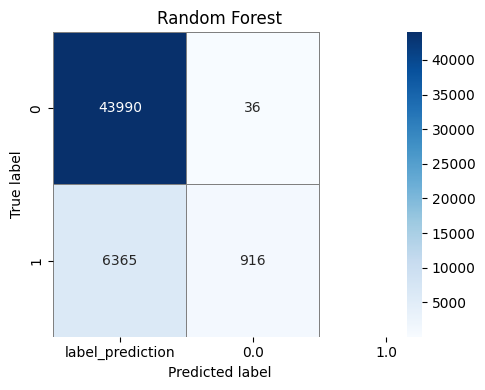

In [66]:
# loop and print the confusion matrix for each model
for model_name, conf_matrix in confusion_matrices.items():
    df_model_confusion_matrix = confusion_matrices[model_name].toPandas()
    plt.figure(figsize=(5, 4))
    sns.heatmap(
    df_model_confusion_matrix.set_index("label_prediction"),
    annot=True,          # show the numbers in each cell
    fmt='d',             # integer format
    cmap='Blues',        # blue colour map
    linewidths=0.5,
    linecolor='gray',
    xticklabels=df_model_confusion_matrix.columns,
    yticklabels=df_model_confusion_matrix.index
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"{model_name}")
    plt.tight_layout()
    plt.show()

<Axes: xlabel='Model'>

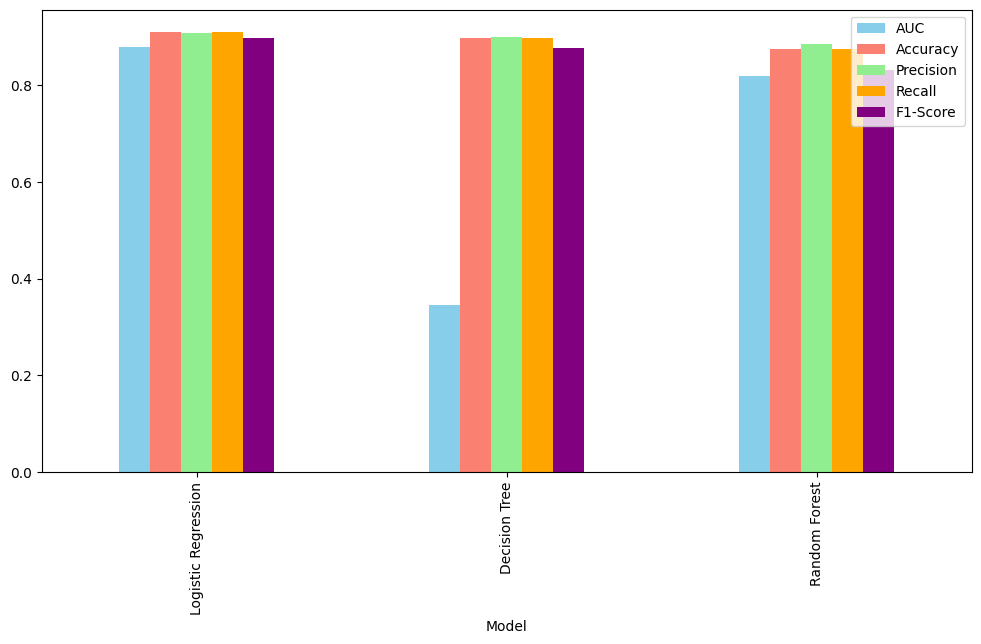

In [67]:
# make visualisation for the confusion matrix of each model, horizontal bar chart for the performance metrics of each model
results_df = pd.DataFrame(model_results).T.reset_index().rename(columns={"index": "Model"})
results_df.plot(x="Model", y=["AUC", "Accuracy", "Precision", "Recall", "F1-Score"], kind="bar", figsize=(12, 6), color=['skyblue', 'salmon', 'lightgreen', 'orange', 'purple'])

In [68]:
# Create feature vector
feature_vector_cols_cluster = (["Primary Type_Encoded", "District_Encoded", "Arrest_Binary","Domestic_Binary", "Beat_Encoded", "Community Area_Encoded"] +
                       ["Hour", "IsNight"])


assembler_cluster = VectorAssembler(inputCols=feature_vector_cols_cluster, outputCol="features")
df_features_cluster = assembler_cluster.transform(df_encoded)


# Split data into training (80%) and validation (20%)
train_data_cluster, val_data_cluster = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"Training set size: {train_data_cluster.count():,} rows")
print(f"Validation set size: {val_data_cluster.count():,} rows")
print(f"Label distribution in training set:")
train_data_cluster.groupBy("label").count().show()

Training set size: 206,214 rows
Validation set size: 51,307 rows
Label distribution in training set:
+-----+------+
|label| count|
+-----+------+
|    1| 28419|
|    0|177795|
+-----+------+



# PART 04: CLUSTERING MODEL

In [69]:
# PART 04: CLUSTERING MODEL TASK
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import StandardScaler

# Prepare clustering features
clustering_features = (["Primary Type_Encoded", "District_Encoded", "Arrest_Binary","Domestic_Binary", "Beat_Encoded"]+
["Community Area_Encoded","Hour", "IsNight"])

# Build clustering dataset
clustering_assembler = VectorAssembler(inputCols=clustering_features, outputCol="features")
df_clustering = clustering_assembler.transform(df_encoded)

# Standardize features for clustering
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(df_clustering)
df_scaled = scaler_model.transform(df_clustering)

print(f"Data prepared for clustering: {df_scaled.count():,} records")
print(f"Features used: {', '.join(clustering_features)}")

# K-Means Clustering with different k values
print("\nTesting different cluster counts", list(range(2, 8)), "...")
silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(k=k, seed=42, maxIter=20)
    model = kmeans.fit(df_scaled)
    predictions = model.transform(df_scaled)

    # Calculate Silhouette Score (simple calculation)
    from pyspark.ml.evaluation import ClusteringEvaluator
    evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='scaled_features', metricName='silhouette')
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append((k, silhouette))
    print(f"  k={k}: Silhouette Score = {silhouette:.4f}")


Data prepared for clustering: 257,521 records
Features used: Primary Type_Encoded, District_Encoded, Arrest_Binary, Domestic_Binary, Beat_Encoded, Community Area_Encoded, Hour, IsNight

Testing different cluster counts [2, 3, 4, 5, 6, 7] ...
  k=2: Silhouette Score = 0.0059
  k=3: Silhouette Score = 0.0016
  k=4: Silhouette Score = -0.0005
  k=5: Silhouette Score = -0.0059
  k=6: Silhouette Score = -0.0032
  k=7: Silhouette Score = -0.0071


In [70]:
# Get optimal k based on silhouette scores
optimal_k = int
k_score = 0
for score in silhouette_scores:
    if score[1] > k_score:
        k_score = score[1]
        optimal_k = score[0]

print(f"\nUsing k={optimal_k} for final clustering model...")
kmeans_final = KMeans(k=optimal_k, seed=42, maxIter=20)
kmeans_model = kmeans_final.fit(df_scaled)
df_clustered = kmeans_model.transform(df_scaled)

print(f"Clustering completed! Created {optimal_k} clusters")
print("\nCluster Distribution:")
df_clustered.groupBy("prediction").count().show()


Using k=2 for final clustering model...
Clustering completed! Created 2 clusters

Cluster Distribution:
+----------+------+
|prediction| count|
+----------+------+
|         1|164856|
|         0| 92665|
+----------+------+



In [71]:
# Cluster Profiling and Interpretation
# Join clustered data with original features
df_profile = df_clustered.select("prediction", *clustering_features)

for cluster_id in range(optimal_k):
    print(f"\nCluster {cluster_id}:")
    cluster_data = df_profile.filter(col("prediction") == cluster_id)
    cluster_size = cluster_data.count()

    print(f"  Size: {cluster_size:,} incidents ({cluster_size/df_clustered.count()*100:.1f}%)")

    # Calculate statistics for each feature
    stats = cluster_data.select(
        avg("Hour").alias("Avg_Hour"),
        avg("IsNight").alias("Night_Ratio"),
        avg("Domestic_Binary").alias("Domestic_Ratio")
    ).collect()[0]

    print(f"  Average Hour: {stats['Avg_Hour']:.1f}")
    print(f"  Night Incidents: {stats['Night_Ratio']*100:.1f}%")
    print(f"  Domestic Related: {stats['Domestic_Ratio']*100:.1f}%")

    # Characterize cluster
    if stats['Night_Ratio'] > 0.5:
        print(f"  -> Characterized as: NIGHTTIME CRIME GROUP")
    elif stats['Domestic_Ratio'] > 0.5:
        print(f"  -> Characterized as: DOMESTIC INCIDENT GROUP")
    else:
        print(f"  -> Characterized as: GENERAL CRIME GROUP")


Cluster 0:
  Size: 92,665 incidents (36.0%)
  Average Hour: 4.8
  Night Incidents: 55.0%
  Domestic Related: 20.2%
  -> Characterized as: NIGHTTIME CRIME GROUP

Cluster 1:
  Size: 164,856 incidents (64.0%)
  Average Hour: 16.9
  Night Incidents: 28.1%
  Domestic Related: 17.3%
  -> Characterized as: GENERAL CRIME GROUP
